In [1]:
import numpy
import gudhi
import matplotlib.pyplot as plt

def collect(st, field, max_dim=2):
    diag = st.persistence(homology_coeff_field=field, min_persistence=0.0)
    dgms = [[] for _ in range(max_dim + 1)]
    for dim, (b, d) in diag:
        if dim > max_dim:
            continue
        b_a = numpy.sqrt(max(b, 0.0))
        d_a = numpy.inf if numpy.isinf(d) else numpy.sqrt(max(d, 0.0))
        dgms[dim].append([b_a, d_a])
    return [numpy.array(d) if d else numpy.empty((0, 2)) for d in dgms]

def measured_betti(dgms, min_life: float = 0.15, min_gap: float = 1.1):
    betti = []
    for dgm in dgms:
        finite = dgm[numpy.isfinite(dgm[:, 1])]
        if len(finite) == 0:
            betti.append(0)
            continue
        lifes = finite[:, 1] - finite[:, 0]
        ps = numpy.sort(lifes[lifes > min_life])[::-1]
        if len(ps) < 2:
            betti.append(len(ps))
            continue
        diffs = ps[:-1] / ps[1:]
        betti.append(numpy.argmax(diffs) + 1)
    return tuple(betti)

def plot_diagram(ax, dgms, title, max_dim=2):
    colors = ["tab:blue", "tab:orange", "tab:green"]
    markers = ["o", "s", "^"]
    scales = []
    for dgm in dgms:
        f = dgm[numpy.isfinite(dgm[:, 1])]
        if len(f):
            scales.append(f[:, 1].max())
    scale = max(scales, default=1.0)
    pad = 0.05 * scale
    ax.plot([0, scale + pad], [0, scale + pad], "k--", linewidth=0.8, alpha=0.6)
    for k in range(max_dim + 1):
        finite = dgms[k][numpy.isfinite(dgms[k][:, 1])]
        if not len(finite):
            continue
        ax.scatter(
            finite[:, 0],
            finite[:, 1],
            c=colors[k],
            marker=markers[k],
            s=40,
            alpha=0.7,
            edgecolors="none",
            label=fr"$H_{k}$"
        )
    ax.set_xlim(-pad, scale + pad)
    ax.set_ylim(-pad, scale + pad)
    ax.set_aspect("equal")
    ax.set_xlabel("birth")
    ax.set_ylabel("death")
    ax.set_title(title, fontsize=11)
    ax.legend(loc="lower right", fontsize=9)
    ax.grid(True, alpha=0.2)

def process(pointcloud):
    complex = gudhi.AlphaComplex(points=pointcloud.tolist(), precision='fast')

    pd2 = collect(complex.create_simplex_tree(), 2)
    print('Z2', measured_betti(pd2))
    
    pd3 = collect(complex.create_simplex_tree(), 3)
    print('Z3', measured_betti(pd3))

    fig, axes = plt.subplots(1, 2, figsize = (10, 5))
    plot_diagram(axes[0], pd2, "Z2")
    plot_diagram(axes[1], pd3, "Z3")

## Torus & Klein bottle

Z2 (2, 2, 1)
Z3 (2, 2, 1)


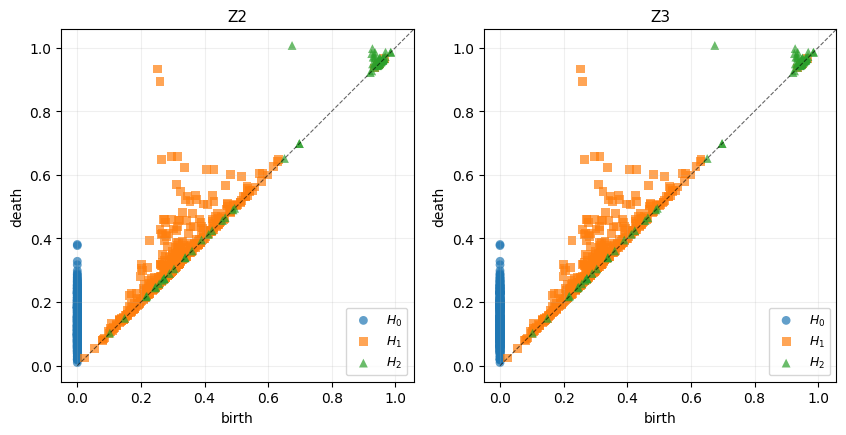

In [13]:
def sample_torus(n, R=2.0, r=1.0, noise=0.0, seed=0):
    rng = numpy.random.RandomState(seed)
    u = rng.uniform(0, 2 * numpy.pi, n)
    v = rng.uniform(0, 2 * numpy.pi, n)

    a = numpy.stack([
        (R + r * numpy.cos(v)) * numpy.cos(u),
        (R + r * numpy.cos(v)) * numpy.sin(u), r * numpy.sin(v)
    ], axis=1)
    return a + (rng.normal(0, noise, (n,3)) if noise > 0 else 0)

process(sample_torus(400, noise=0.05))

Z2 (4, 2, 1)
Z3 (4, 1, 1)


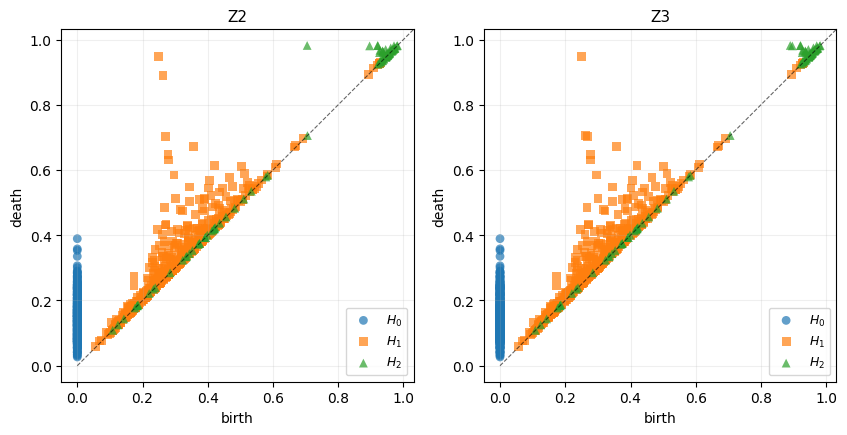

In [14]:
def sample_klein(n, R=2.0, r=1.0, noise=0.0, seed=0):
    rng = numpy.random.RandomState(seed)
    u = rng.uniform(0, 2 * numpy.pi, n)
    v = rng.uniform(0, 2 * numpy.pi, n)
    pts = numpy.stack([
        (R + r * numpy.cos(v)) * numpy.cos(u),
        (R + r * numpy.cos(v)) * numpy.sin(u),
        r * numpy.sin(v) * numpy.cos(u/2),
        r * numpy.sin(v) * numpy.sin(u/2),
    ], axis=1)
    return pts + (rng.normal(0, noise, pts.shape) if noise > 0 else 0)

process(sample_klein(400, noise=0.05))